In [747]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

n = pypsa.Network("/Users/fowfloi/Documents/pypsa-earth/results/nigeria_2024_validation/networks/elec_s_10_ec_lv1.0_1h.nc")
connected = [b for b in n.buses.index if b != "NG1 0"] #To drop the isolated node that is being load shed
connected_gens = n.generators[n.generators.bus.isin(connected)].index
connected_loads = [c for c in n.loads_t.p_set.columns if c in connected]

INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


In [748]:

print(n)
print(f"\nSnapshots: {n.snapshots[0]} -> {n.snapshots[-1]}  ({len(n.snapshots)} hours)")
print(f"Weather / demand year: {n.meta['load_options']['weather_year']}")
print("\n(Reading p_nom / p_max_pu / loads_t.p_set only.)")
print(f"Annual demand: {n.loads_t.p_set.sum().sum()/1e6:.2f} TWh (scale={n.meta['load_options']['scale']})")

PyPSA Network
Components:
 - Bus: 10
 - Carrier: 11
 - Generator: 39
 - GlobalConstraint: 1
 - Line: 10
 - Load: 10
 - StorageUnit: 3
Snapshots: 8784

Snapshots: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00  (8784 hours)
Weather / demand year: 2024

(Reading p_nom / p_max_pu / loads_t.p_set only.)
Annual demand: 37.28 TWh (scale=1)


In [749]:
print(n.storage_units[["bus", "carrier", "p_nom", "max_hours"]].to_string())
print("total:", n.storage_units.p_nom.sum(), "MW")

               bus carrier   p_nom    max_hours
StorageUnit                                    
NG0 1 hydro  NG0 1   hydro  1300.0  1315.384615
NG0 3 hydro  NG0 3   hydro    40.0   200.000000
NG0 5 hydro  NG0 5   hydro  1338.0   873.617339
total: 2678.0 MW


In [750]:
print(n.buses[["x", "y", "v_nom", "carrier"]])
print(f"\n{len(n.lines)} lines, {n.lines.s_nom.sum():,.0f} MW total thermal rating")

               x          y  v_nom carrier
Bus                                       
NG0 0   3.745191   6.981382  330.0      AC
NG0 1   7.320793   9.470453  330.0      AC
NG0 2   5.733617   6.056350  330.0      AC
NG0 3  11.999500  10.427583  330.0      AC
NG0 4   6.891267   7.065125  330.0      AC
NG0 5   4.826160   9.290120  330.0      AC
NG0 6   5.140900  12.682000  330.0      AC
NG0 7   7.790913  11.950788  330.0      AC
NG0 8   7.414333   5.019200  330.0      AC
NG1 0   7.694700   7.713067  330.0      AC

10 lines, 25,168 MW total thermal rating


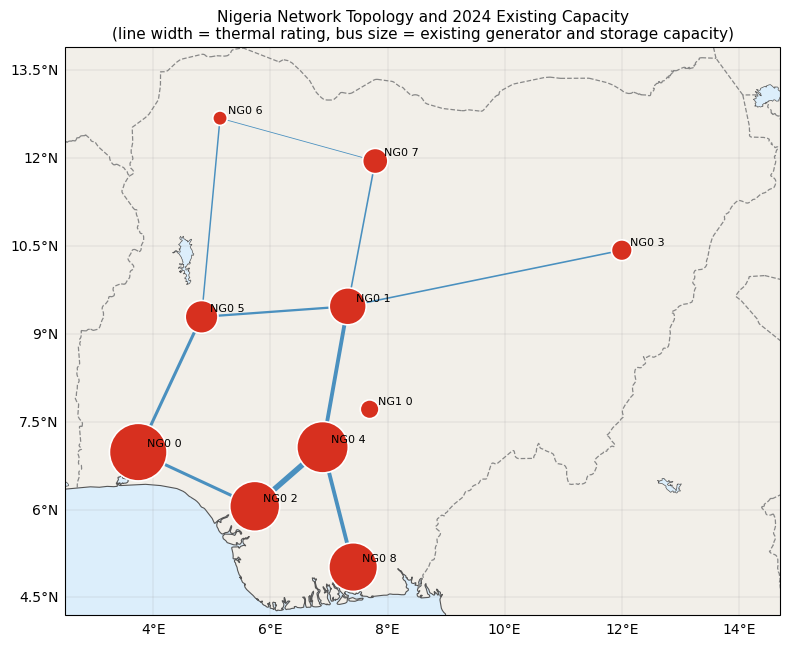

In [751]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([2.5, 14.7, 4.2, 13.9], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555555")
ax.add_feature(cfeature.BORDERS, linewidth=0.9, linestyle="--", edgecolor="#888888")
ax.add_feature(cfeature.LAKES, facecolor="#dceefb", edgecolor="#555555", linewidth=0.5)

# transmission lines, weighted by thermal rating
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    lw = 0.5 + 3.5 * (ln.s_nom / n.lines.s_nom.max()) if n.lines.s_nom.max() > 0 else 1
    ax.plot(
        [b0.x, b1.x],
        [b0.y, b1.y],
        color="#2c7fb8",
        lw=lw,
        alpha=0.85,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# bus markers sized by EXISTING (2024) capacity (generators + storage)
cap = (
    n.generators.groupby("bus")
    .p_nom.sum()
    .add(n.storage_units.groupby("bus").p_nom.sum(), fill_value=0)
)
sizes = 30 + 0.35 * cap.reindex(n.buses.index).fillna(0)

sc = ax.scatter(
    n.buses.x,
    n.buses.y,
    s=sizes,
    c="#d7301f",
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
    transform=ccrs.PlateCarree(),
)
for name, row in n.buses.iterrows():
    ax.annotate(
        name,
        (row.x, row.y),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        transform=ccrs.PlateCarree(),
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax.set_title(
    "Nigeria Network Topology and 2024 Existing Capacity\n"
    "(line width = thermal rating, bus size = existing generator and storage capacity)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("fig1_network_map_nigeria_baseline.png", bbox_inches="tight")
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Total annual demand         : 37.28 TWh
Peak demand                 : 5,181 MW  (at 2024-02-27 18:00:00)
Average demand              : 4,244 MW
Load factor                 : 81.9%
Minimum demand               : 0 MW


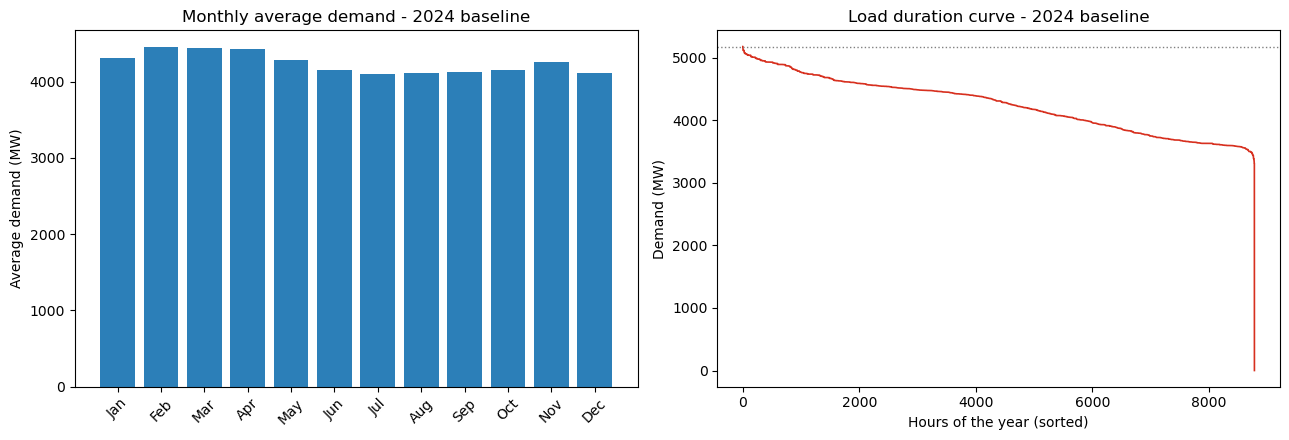

In [752]:
demand = n.loads_t.p_set.sum(axis=1)  # MW, national total, hourly
total_demand_twh = demand.sum() / 1e6
peak_mw = demand.max()
peak_time = demand.idxmax()
mean_mw = demand.mean()
load_factor = mean_mw / peak_mw

print(f"Total annual demand         : {total_demand_twh:.2f} TWh")
print(f"Peak demand                 : {peak_mw:,.0f} MW  (at {peak_time})")
print(f"Average demand              : {mean_mw:,.0f} MW")
print(f"Load factor                 : {load_factor:.1%}")
print(f"Minimum demand               : {demand.min():,.0f} MW")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

monthly = demand.resample("ME").mean()
axes[0].bar(monthly.index.strftime("%b"), monthly.values, color="#2c7fb8")
axes[0].set_ylabel("Average demand (MW)")
axes[0].set_title("Monthly average demand - 2024 baseline")
axes[0].tick_params(axis="x", rotation=45)

duration = np.sort(demand.values)[::-1]
hours = np.arange(1, len(duration) + 1)
axes[1].plot(hours, duration, color="#d7301f", lw=1.2)
axes[1].axhline(peak_mw, color="gray", ls=":", lw=1)
axes[1].set_xlabel("Hours of the year (sorted)")
axes[1].set_ylabel("Demand (MW)")
axes[1].set_title("Load duration curve - 2024 baseline")

plt.tight_layout()
plt.savefig("fig2_baseline_demand.png", bbox_inches="tight")
plt.show()

        Model (ERA5 2024)  Nigeria benchmark
solar               0.179               0.18
onwind              0.084                NaN

Solar CF by bus, north to south:
                lat     cf
Generator                 
NG0 6 solar  12.682  0.195
NG0 7 solar  11.951  0.198
NG0 3 solar  10.428  0.195
NG0 1 solar   9.470  0.186
NG0 5 solar   9.290  0.185
NG1 0 solar   7.713  0.193
NG0 4 solar   7.065  0.172
NG0 0 solar   6.981  0.164
NG0 2 solar   6.056  0.151
NG0 8 solar   5.019  0.148


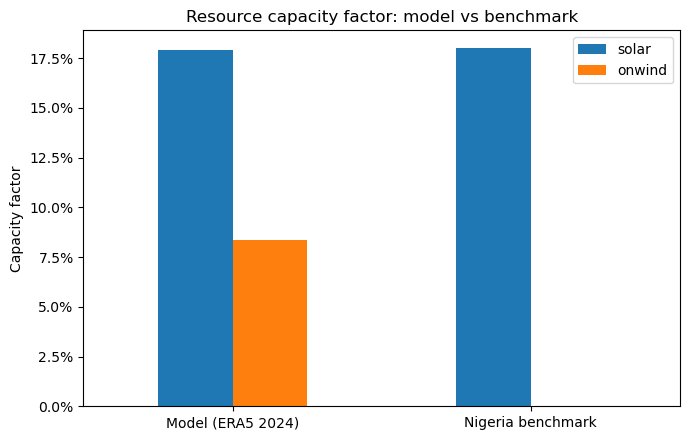

In [753]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

solar_gens = n.generators[n.generators.carrier == "solar"].index
onwind_gens = n.generators[n.generators.carrier == "onwind"].index

model_cf = {
    "solar": n.generators_t.p_max_pu[solar_gens].mean().mean(),
    "onwind": n.generators_t.p_max_pu[onwind_gens].mean().mean(),
}

cf_summary = pd.DataFrame({
    "Model (ERA5 2024)": {"solar": model_cf["solar"], "onwind": model_cf["onwind"]},
    "Nigeria benchmark": {"solar": 0.18, "onwind": float("nan")},
})
print(cf_summary.round(3))

# per bus solar CF, sorted by latitude: this is the north to south gradient
solar_by_bus = pd.DataFrame({
    "lat": n.buses.loc[n.generators.loc[solar_gens, "bus"], "y"].values,
    "cf": n.generators_t.p_max_pu[solar_gens].mean().values,
}, index=solar_gens).sort_values("lat", ascending=False)
print("\nSolar CF by bus, north to south:")
print(solar_by_bus.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
cf_summary.T.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Capacity factor")
ax.set_title("Resource capacity factor: model vs benchmark")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig4_resource_cf_nigeria.png", bbox_inches="tight")
plt.show()

In [754]:
from atlite.resource import get_windturbineconfig
import numpy as np

def turbine_summary(name):
    cfg = get_windturbineconfig(name)
    V, POW, P = np.array(cfg["V"]), np.array(cfg["POW"]), cfg["P"]
    cut_in = V[POW > 0][0]
    rated = V[POW >= P * 0.999][0]
    cut_out = V[POW > 0][-1]
    print(f"{name}: hub {cfg['hub_height']} m, rated {P} MW, "
          f"cut in {cut_in} m/s, rated speed {rated} m/s, cut out {cut_out} m/s")

for t in ["Vestas_V112_3MW", "Vestas_V90_3MW", "Enercon_E126_7500kW"]:
    turbine_summary(t)

Vestas_V112_3MW: hub 80.0 m, rated 3.06 MW, cut in 3 m/s, rated speed 13 m/s, cut out 25 m/s
Vestas_V90_3MW: hub 80.0 m, rated 3.0 MW, cut in 4 m/s, rated speed 15 m/s, cut out 25 m/s
Enercon_E126_7500kW: hub 135 m, rated 7.58 MW, cut in 3 m/s, rated speed 17 m/s, cut out 28 m/s


/opt/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/atlite/resource.py:90: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.
  warnings.warn(msg, FutureWarning)


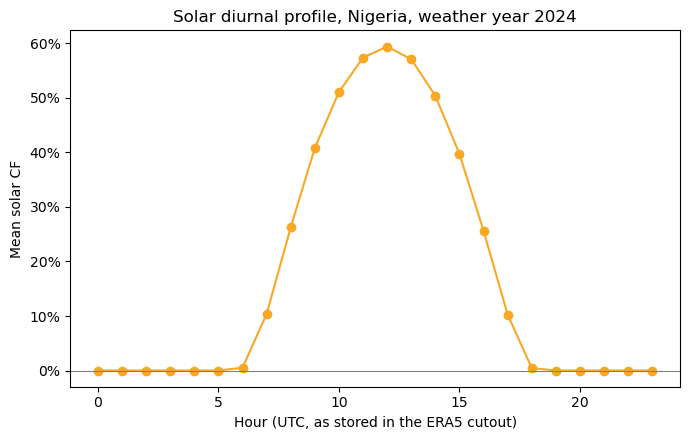

Max CF during night hours (expect ~0): 0.0000
Peak CF hour: 12:00 UTC = 13:00 local (WAT), CF 0.594


In [755]:
# --- Solar diurnal shape check: is the profile physically plausible for Nigeria? ---
# Purpose: catch timezone or UTC offset bugs in the cutout before trusting any CF number.

solar_p_max_pu = n.generators_t.p_max_pu[solar_gens]

# Mean CF by hour of day, averaged across all buses and all days of 2024
diurnal = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.hour).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
diurnal.plot(ax=ax, marker="o", color="#f9a825")
ax.set_xlabel("Hour (UTC, as stored in the ERA5 cutout)")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar diurnal profile, Nigeria, weather year 2024")
ax.axhline(0, color="grey", lw=0.8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig_solar_diurnal_nigeria.png", bbox_inches="tight")
plt.show()

# --- Sanity checks ---
# NOTE ON TIMEZONE: atlite stores cutout time in UTC. Nigeria is UTC+1 (WAT, no DST).
# Solar noon in UTC = 12:00 minus (longitude / 15) hours. My buses span roughly
# 3.7E to 12.0E, so solar noon falls between about 11:12 and 11:45 UTC.
# I therefore expect the peak in the 11:00 UTC bin, which is 12:00 local.
night_hours = list(range(0, 5)) + list(range(19, 24))   # UTC; expect ~0
peak_hour = diurnal.idxmax()
peak_cf = diurnal.max()
night_cf = diurnal.loc[diurnal.index.isin(night_hours)].max()

print(f"Max CF during night hours (expect ~0): {night_cf:.4f}")
print(f"Peak CF hour: {peak_hour}:00 UTC = {peak_hour + 1}:00 local (WAT), CF {peak_cf:.3f}")

assert night_cf < 0.01, (
    "Non zero solar CF at night. Likely a UTC offset bug in the cutout time coordinate."
)
assert 10 <= peak_hour <= 13, (
    f"Peak at {peak_hour}:00 UTC is outside the expected 11:00 UTC window for Nigerian "
    "longitudes. Check the cutout time coordinate before using these profiles."
)

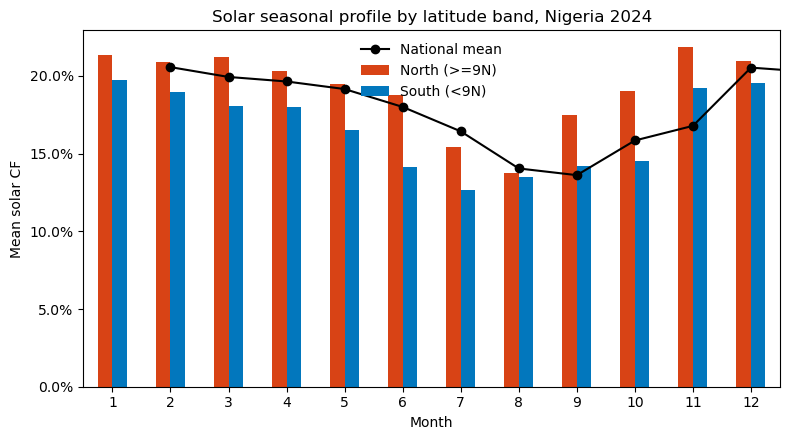

          North (>=9N)  South (<9N)  National
snapshot                                     
1                0.214        0.198     0.206
2                0.209        0.189     0.199
3                0.212        0.180     0.196
4                0.203        0.180     0.192
5                0.195        0.165     0.180
6                0.187        0.141     0.164
7                0.154        0.127     0.140
8                0.138        0.135     0.136
9                0.175        0.142     0.158
10               0.190        0.145     0.168
11               0.218        0.192     0.205
12               0.210        0.195     0.203

North, Harmattan months (Dec to Feb):        0.211
North, shoulder months (Mar, Apr, Oct, Nov): 0.206
North, wet season (Jun to Sep):              0.164

South, dry season (Dec to Feb):              0.194
South, wet season (Apr to Oct):              0.148

FLAG: no Harmattan dip in the northern series. Consistent with the known ERA5 aerosol underreprese

In [756]:
# --- Solar seasonal shape check, split north and south ---
# Nigeria spans roughly 4N to 14N, so a national monthly average conflates two
# distinct climate regimes. I split at 9N, the same band boundary I use for the
# CF correction.
#
# WHAT I EXPECT:
#   South (Niger Delta, Lagos): long wet season roughly March to October, heavy
#     cloud, suppressed CF. Peak CF in the December to February dry window.
#   North (Sokoto, Kano, Maiduguri): short wet season June to September. The dry
#     season is not automatically the high CF season, because Harmattan (roughly
#     December to February) carries heavy Saharan dust that cuts direct irradiance
#     even under cloudless skies. I expect the northern annual peak in the shoulder
#     months, after the dust clears and before the rains, around March to April,
#     and again in October to November.
#
# DIAGNOSTIC VALUE: ERA5 is documented to underrepresent aerosol loading. If the
# northern series shows no December to February dip, that points to the ERA5
# aerosol bias rather than a real feature of the Nigerian resource, and it
# justifies deriving my solar correction factor monthly rather than as a single
# annual scalar.

solar_bus = n.generators.loc[solar_gens, "bus"]
solar_lat = n.buses.loc[solar_bus, "y"]
solar_lat.index = solar_gens

north_gens = solar_lat[solar_lat >= 9.0].index
south_gens = solar_lat[solar_lat < 9.0].index

monthly_all = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.month).mean()
monthly_north = solar_p_max_pu[north_gens].mean(axis=1).groupby(solar_p_max_pu.index.month).mean()
monthly_south = solar_p_max_pu[south_gens].mean(axis=1).groupby(solar_p_max_pu.index.month).mean()

seasonal = pd.DataFrame({
    "North (>=9N)": monthly_north,
    "South (<9N)": monthly_south,
    "National": monthly_all,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
seasonal[["North (>=9N)", "South (<9N)"]].plot(ax=ax, kind="bar", rot=0,
                                               color=["#d84315", "#0277bd"])
seasonal["National"].plot(ax=ax, color="black", marker="o", lw=1.5, label="National mean")
ax.set_xlabel("Month")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar seasonal profile by latitude band, Nigeria 2024")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig_solar_seasonal_nigeria.png", bbox_inches="tight")
plt.show()

print(seasonal.round(3).to_string())

harmattan = [12, 1, 2]
shoulder = [3, 4, 10, 11]
print(f"\nNorth, Harmattan months (Dec to Feb):        {monthly_north.loc[harmattan].mean():.3f}")
print(f"North, shoulder months (Mar, Apr, Oct, Nov): {monthly_north.loc[shoulder].mean():.3f}")
print(f"North, wet season (Jun to Sep):              {monthly_north.loc[6:9].mean():.3f}")
print(f"\nSouth, dry season (Dec to Feb):              {monthly_south.loc[harmattan].mean():.3f}")
print(f"South, wet season (Apr to Oct):              {monthly_south.loc[4:10].mean():.3f}")

if monthly_north.loc[harmattan].mean() >= monthly_north.loc[shoulder].mean():
    print("\nFLAG: no Harmattan dip in the northern series. Consistent with the known "
          "ERA5 aerosol underrepresentation. Derive the solar correction monthly.")

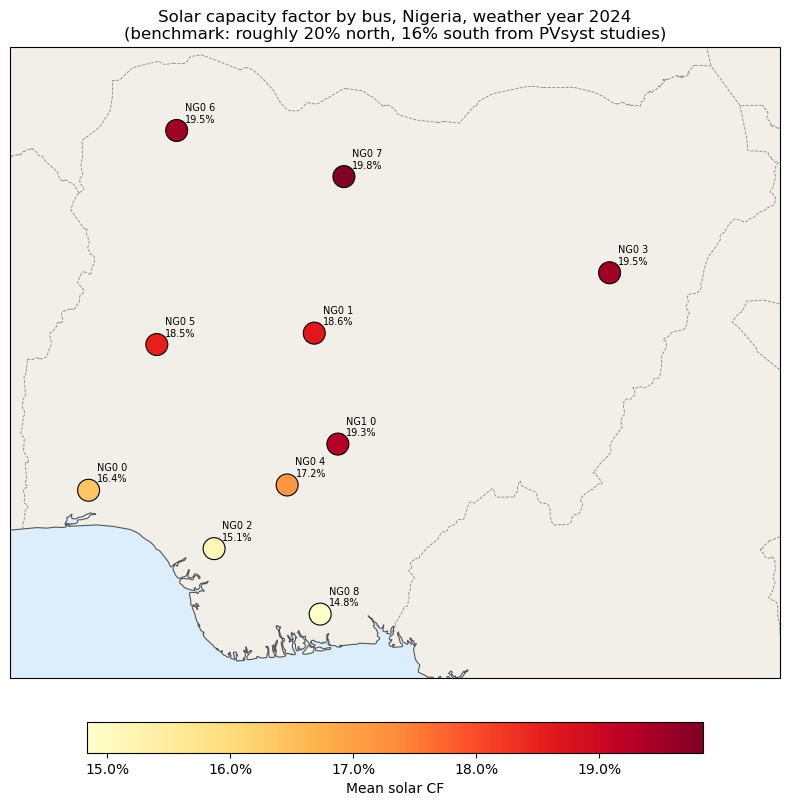

          lat  mean_CF
NG0 6  12.682    0.195
NG0 7  11.951    0.198
NG0 3  10.428    0.195
NG0 1   9.470    0.186
NG0 5   9.290    0.185
NG1 0   7.713    0.193
NG0 4   7.065    0.172
NG0 0   6.981    0.164
NG0 2   6.056    0.151
NG0 8   5.019    0.148


In [757]:
# --- Spatial pattern of solar CF across the 10 node network ---
# This is the visual check on the north to south irradiance gradient. If the gradient is
# absent or inverted, either clustering has averaged it away or the profile build is wrong.

import cartopy.crs as ccrs
import cartopy.feature as cfeature

per_gen_cf = solar_p_max_pu.mean()
gen_to_bus = n.generators.loc[per_gen_cf.index, "bus"]
bus_cf = pd.Series(per_gen_cf.values, index=gen_to_bus.values, name="mean_CF")
bus_cf = bus_cf.groupby(bus_cf.index).mean()   # in case several solar gens share a bus
bus_coords = n.buses.loc[bus_cf.index, ["x", "y"]]

fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([2.5, 14.7, 4.0, 14.0], crs=ccrs.PlateCarree())   # Nigeria

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    bus_coords["x"], bus_coords["y"],
    c=bus_cf.values, cmap="YlOrRd",
    s=250, edgecolor="black", linewidth=0.8,
    transform=ccrs.PlateCarree(), zorder=5,
)

for bus, (x, y) in bus_coords.iterrows():
    ax.annotate(f"{bus}\n{bus_cf[bus]:.1%}", (x, y),
                textcoords="offset points", xytext=(6, 6),
                fontsize=7, transform=ccrs.PlateCarree())

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean solar CF")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.set_title("Solar capacity factor by bus, Nigeria, weather year 2024\n"
             "(benchmark: roughly 20% north, 16% south from PVsyst studies)")
plt.tight_layout()
plt.savefig("fig_solar_cf_map_nigeria.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame({"lat": bus_coords["y"], "mean_CF": bus_cf})
      .sort_values("lat", ascending=False).round(3).to_string())

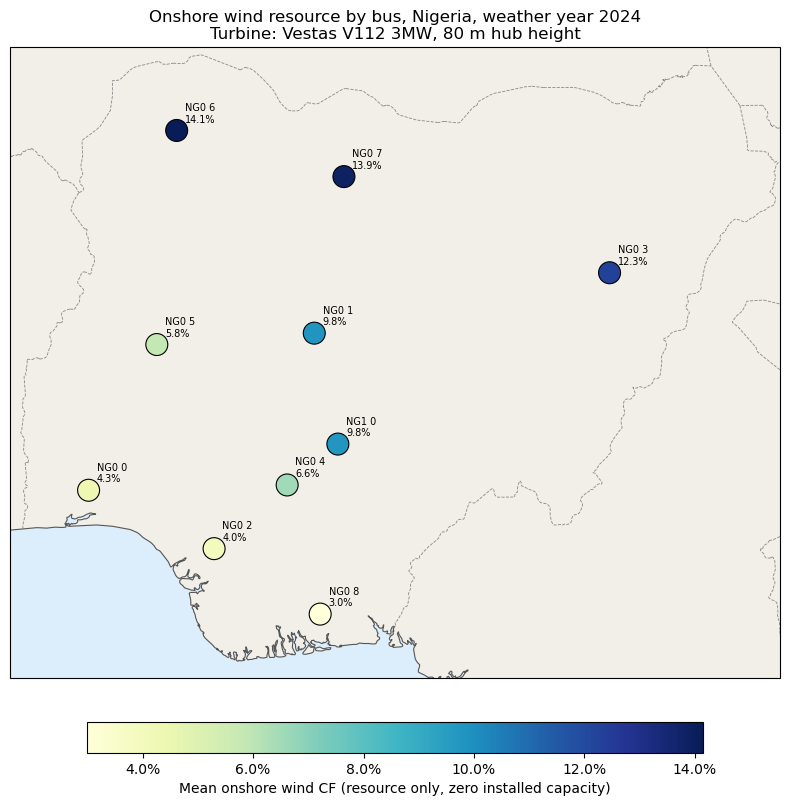

          lat  mean_CF
NG0 6  12.682    0.141
NG0 7  11.951    0.139
NG0 3  10.428    0.123
NG0 1   9.470    0.098
NG1 0   7.713    0.098
NG0 4   7.065    0.066
NG0 5   9.290    0.058
NG0 0   6.981    0.043
NG0 2   6.056    0.040
NG0 8   5.019    0.030


In [758]:
# --- Spatial pattern of onshore wind CF ---
# NOTE: installed wind capacity in this model is ZERO (IRENA reports none for Nigeria).
# These generators exist with p_nom = 0, so this map shows the RESOURCE, not generation.
# It is here because wind becomes a live variable in the 2030 expansion run, where the
# northern sites (Katsina, Kano, Sokoto) are the only ones likely to be economic.
#
# Offshore wind is excluded from this model via electricity.renewable_carriers, so there
# is no offshore series to plot.

import cartopy.crs as ccrs
import cartopy.feature as cfeature

onwind_gens = n.generators[n.generators.carrier == "onwind"].index
onwind_p_max_pu = n.generators_t.p_max_pu[onwind_gens]

per_gen_cf = onwind_p_max_pu.mean()
gen_to_bus = n.generators.loc[per_gen_cf.index, "bus"]
onwind_bus_cf = pd.Series(per_gen_cf.values, index=gen_to_bus.values, name="mean_CF")
onwind_bus_cf = onwind_bus_cf.groupby(onwind_bus_cf.index).mean()
onwind_coords = n.buses.loc[onwind_bus_cf.index, ["x", "y"]]

fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([2.5, 14.7, 4.0, 14.0], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    onwind_coords["x"], onwind_coords["y"],
    c=onwind_bus_cf.values, cmap="YlGnBu",
    s=250, edgecolor="black", linewidth=0.8,
    transform=ccrs.PlateCarree(), zorder=5,
)

for bus, (x, y) in onwind_coords.iterrows():
    ax.annotate(f"{bus}\n{onwind_bus_cf[bus]:.1%}", (x, y),
                textcoords="offset points", xytext=(6, 6),
                fontsize=7, transform=ccrs.PlateCarree())

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean onshore wind CF (resource only, zero installed capacity)")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.set_title("Onshore wind resource by bus, Nigeria, weather year 2024\n"
             "Turbine: Vestas V112 3MW, 80 m hub height")
plt.tight_layout()
plt.savefig("fig_wind_cf_map_nigeria.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame({"lat": onwind_coords["y"], "mean_CF": onwind_bus_cf})
      .sort_values("mean_CF", ascending=False).round(3).to_string())

In [759]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)

In [760]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)
print(demand_shares.round(1))

Load
NG0 4    22.3
NG0 0    19.7
NG0 7    13.6
NG0 1     9.9
NG0 8     9.1
NG0 3     7.2
NG1 0     6.9
NG0 2     5.3
NG0 6     3.6
NG0 5     2.6
dtype: float64


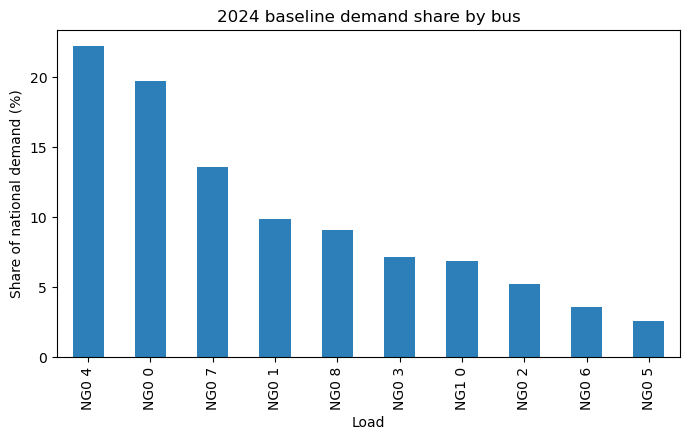

In [761]:
fig, ax = plt.subplots(figsize=(7, 4.5))
demand_shares.plot.bar(ax=ax, color="#2c7fb8")
ax.set_ylabel("Share of national demand (%)")
ax.set_title("2024 baseline demand share by bus")
plt.tight_layout()
plt.savefig("fig2b_demand_shares.png", bbox_inches="tight")
plt.show()

In [762]:
gen_by_carrier_gwh = (
    n.generators_t.p.T.groupby(n.generators.carrier)
    .sum()
    .T.sum()
    .add(
        n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T.sum(),
        fill_value=0,
    )
) / 1e3  # MWh -> GWh

gen_share_pct = (gen_by_carrier_gwh / gen_by_carrier_gwh.sum() * 100).round(2)

carrier_map = {
    "CCGT": "thermal",
    "OCGT": "thermal",
    "biomass": "thermal",
    "hydro": "hydro",
    "ror": "hydro",
    "solar": "solar",
    "onwind": "wind",
    "offwind-ac": "wind",
    "offwind-dc": "wind",
    "load shedding": "load shedding",
}
gen_share_grouped = (
    gen_share_pct.rename(index=carrier_map)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)
print(gen_share_grouped.round(2))

print(gen_share_pct.sort_values(ascending=False))

carrier
thermal          63.90
hydro            22.67
load shedding    12.71
solar             0.72
wind              0.00
dtype: float64
carrier
OCGT             39.07
CCGT             24.83
hydro            22.67
load shedding    12.71
solar             0.72
onwind            0.00
dtype: float64


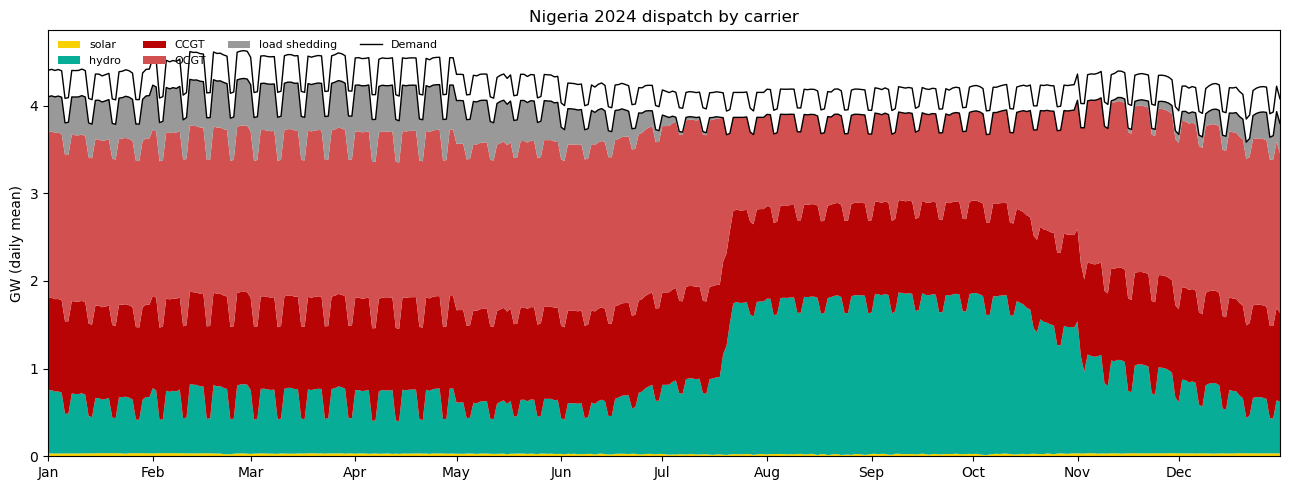

In [763]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 2024 dispatch by carrier, as solved. No expansion, no CO2 constraint.
# Generators and storage dispatch are combined so hydro appears alongside thermal.

gen = (n.generators_t.p[connected_gens].T
       .groupby(n.generators.loc[connected_gens].carrier).sum().T)
sto = n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T
dispatch = pd.concat([gen, sto], axis=1).T.groupby(level=0).sum().T

# drop carriers that never dispatch, so the legend stays readable
dispatch = dispatch.loc[:, dispatch.sum() > 0]

# stack in merit order, cheapest at the bottom
order = ["solar", "onwind", "ror", "hydro", "biomass", "oil", "CCGT", "OCGT", "load"]
cols = [c for c in order if c in dispatch.columns] + \
       [c for c in dispatch.columns if c not in order]
dispatch = dispatch[cols]

colors = {
    "solar": "#f9d002", "onwind": "#235ebc", "hydro": "#08ad97", "ror": "#4adbc8",
    "biomass": "#0c6013", "oil": "#262626", "CCGT": "#b80404", "OCGT": "#d35050",
    "load": "#ff0000",
}
palette = [colors.get(c, "#999999") for c in dispatch.columns]

# --- Full year, daily mean to keep 8784 hours legible ---
daily = dispatch.resample("D").mean() / 1e3   # MW -> GW

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(daily.index, daily.T.values, labels=daily.columns, colors=palette)
ax.plot(n.loads_t.p_set.sum(axis=1).resample("D").mean() / 1e3,
        color="black", lw=1.0, label="Demand")
ax.set_ylabel("GW (daily mean)")
ax.set_title("Nigeria 2024 dispatch by carrier")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=4, frameon=False, fontsize=8)
ax.margins(x=0)
ax.plot(n.loads_t.p_set[connected_loads].sum(axis=1).resample("D").mean() / 1e3,
        color="black", lw=1.0, label="Demand")
plt.tight_layout()
plt.savefig("fig_dispatch_2024_daily.png", bbox_inches="tight")
plt.show()



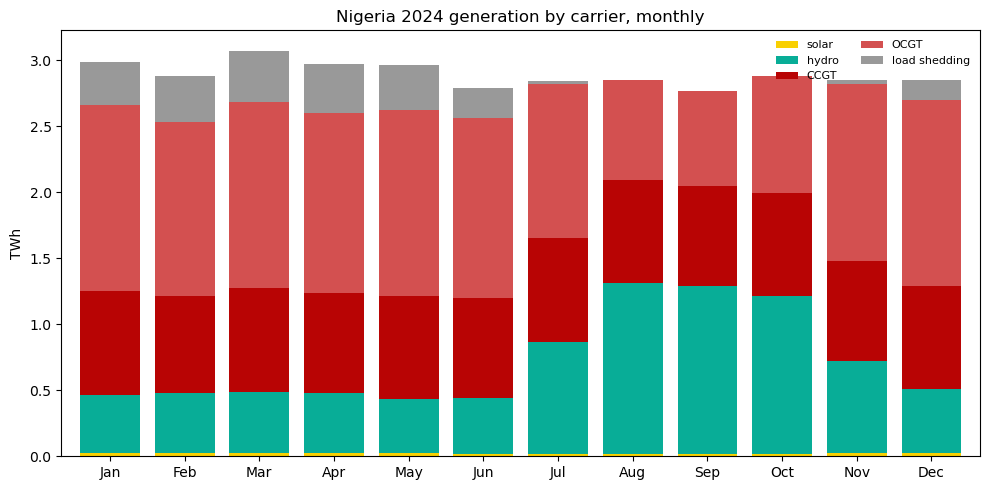

carrier     solar  hydro   CCGT   OCGT  load shedding
snapshot                                             
2024-01-31  0.025  0.443  0.784  1.411          0.323
2024-02-29  0.023  0.456  0.733  1.320          0.353
2024-03-31  0.024  0.467  0.784  1.411          0.389
2024-04-30  0.022  0.457  0.759  1.366          0.367
2024-05-31  0.022  0.411  0.784  1.411          0.341
2024-06-30  0.019  0.423  0.759  1.366          0.222
2024-07-31  0.016  0.853  0.784  1.170          0.020
2024-08-31  0.017  1.295  0.784  0.757          0.000
2024-09-30  0.018  1.269  0.759  0.722          0.000
2024-10-31  0.020  1.193  0.784  0.886          0.000
2024-11-30  0.024  0.700  0.759  1.338          0.031
2024-12-31  0.025  0.484  0.783  1.409          0.151

Annual total: 34.72 TWh

Share by carrier (%):
carrier
OCGT             41.95
CCGT             26.66
hydro            24.34
load shedding     6.33
solar             0.73


In [764]:
monthly = dispatch.resample("ME").sum() / 1e6   # MWh -> TWh

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", stacked=True, ax=ax, color=palette, width=0.8)
ax.set_ylabel("TWh")
ax.set_xlabel("")
ax.set_title("Nigeria 2024 generation by carrier, monthly")
ax.set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=0)
ax.legend(loc="upper right", ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("fig_dispatch_2024_monthly.png", bbox_inches="tight")
plt.show()

print(monthly.round(3).to_string())
print(f"\nAnnual total: {monthly.sum().sum():.2f} TWh")
print("\nShare by carrier (%):")
print((monthly.sum() / monthly.sum().sum() * 100).round(2).sort_values(ascending=False).to_string())

In [765]:
total_system_cost = n.objective + n.objective_constant
print(f"Total system cost (obj + constant): ${total_system_cost:,.0f} USD")

Total system cost (obj + constant): $1,913,690,805 USD


In [766]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas        3444.00000          3444.00000   
            Load shedding             6216.64328          6216.64328   
            Open-Cycle Gas            8740.00000          8740.00000   
            Solar                      174.51815           174.51815   
Line        Ac                       25167.66818         25167.66818   
Load        -                            0.00000             0.00000   
StorageUnit Reservoir & Dam           2678.00000          2678.00000   

                                      Supply    Withdrawal  Energy Balance  \
Generator   Combined-Cycle Gas  9.230795e+06  0.000000e+00    9.230795e+06   
            Load shedding       4.724258e+06  0.000000e+00    4.724258e+06   
            Open-Cycle Gas      1.452597e+07  0.000000e+00    1.452597e+07   
            Solar               2.693518e+05  0.000000e+00    2.693518e+05   
Line        Ac                  2.764343e+07  2.764343e+07    0.000000e+00   
Load        -                   0.000000e+00  3.717839e+07   -3.717839e+07   
StorageUnit Reservoir & Dam     8.428020e+06  0.000000e+00    8.428020e+06   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas         0.000         0.305965  1.053674e+03   
            Load shedding              0.000         0.086751  4.973354e+07   
            Open-Cycle Gas             0.000         0.189727  2.088074e+06   
            Solar                      0.000         0.176188  2.987800e-01   
Line        Ac                    333116.292         0.125385  0.000000e+00   
Load        -                          0.000              NaN  0.000000e+00   
StorageUnit Reservoir & Dam            0.000         0.359262  1.503126e+07   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         4.110637e+08             1.404924e+08   
            Load shedding              0.000000e+00             1.511805e+09   
            Open-Cycle Gas             4.782706e+08             2.524599e+08   
            Solar                      8.942293e+06             2.664546e+03   
Line        Ac                         3.417873e+08             0.000000e+00   
Load        -                          0.000000e+00             0.000000e+00   
StorageUnit Reservoir & Dam            0.000000e+00             8.930401e+06   

                                     Revenue  Market Value  
Generator   Combined-Cycle Gas  2.073872e+09  2.246688e+02  
            Load shedding       1.511805e+09  3.200091e+02  
            Open-Cycle Gas      3.695972e+09  2.544390e+02  
            Solar               6.529064e+07  2.423991e+02  
Line        Ac                  3.315800e+00  1.204192e-07  
Load        -                  -8.680203e+09           NaN  
StorageUnit Reservoir & Dam     1.333264e+09  1.581942e+02

In [767]:
import pandas as pd

tcn = pd.read_csv("/Users/fowfloi/Documents/PHD_Program/PHD_program/Year 2/Papaer 1 workplan/Paper_1_thesis/Data/Processed/nigeria_generation_final.csv", parse_dates=["datetime"])
tcn = tcn[tcn.datetime.dt.year == 2024].set_index("datetime")

hydro_cols = ["KAINJI","JEBBA","SHIRORO","DADIN KOWA","ZUNGERU","KASHAMBILLA"]
for c in hydro_cols + ["GRAND TOTAL"]:
    tcn[c] = pd.to_numeric(tcn[c], errors="coerce")

tcn_hydro = tcn[hydro_cols].sum(axis=1).resample("ME").sum() / 1e6
model_hydro = monthly["hydro"]

cmp = pd.DataFrame({"TCN": tcn_hydro.values, "Model": model_hydro.values},
                   index=[d.strftime("%b") for d in tcn_hydro.index])
cmp["diff_%"] = (cmp.Model - cmp.TCN) / cmp.TCN * 100
print(cmp.round(3).to_string())
print(f"\nAnnual: TCN {cmp.TCN.sum():.2f} vs Model {cmp.Model.sum():.2f} TWh")
print(f"Monthly correlation: {cmp.TCN.corr(cmp.Model):.3f}")
print(f"Suggested multiplier: {cmp.TCN.sum()/cmp.Model.sum():.3f}")

       TCN  Model  diff_%
Jan  0.777  0.443 -43.077
Feb  0.736  0.456 -38.061
Mar  0.754  0.467 -38.105
Apr  0.666  0.457 -31.343
May  0.875  0.411 -53.008
Jun  0.782  0.423 -45.888
Jul  0.950  0.853 -10.220
Aug  1.033  1.295  25.296
Sep  0.971  1.269  30.791
Oct  0.966  1.193  23.435
Nov  0.946  0.700 -25.956
Dec  1.018  0.484 -52.410

Annual: TCN 10.47 vs Model 8.45 TWh
Monthly correlation: 0.697
Suggested multiplier: 1.239


In [768]:
import pandas as pd

path = "/Users/fowfloi/Documents/PHD_Program/PHD_program/Year 2/Papaer 1 workplan/Paper_1_thesis/Data/Processed/nigeria_generation_final.csv"
tcn = pd.read_csv(path, parse_dates=["datetime"])
tcn = tcn[tcn.datetime.dt.year == 2024].set_index("datetime")
tcn["GRAND TOTAL"] = pd.to_numeric(tcn["GRAND TOTAL"], errors="coerce")

tcn_total = tcn["GRAND TOTAL"].resample("ME").sum() / 1e6

# Exclude load shedding: it is unserved demand, not generation, so it has no
# counterpart in the TCN record.
real_gen_cols = [c for c in monthly.columns if c != "load shedding"]
model_total = monthly[real_gen_cols].sum(axis=1)

cmp_tot = pd.DataFrame({"TCN": tcn_total.values, "Model": model_total.values},
                       index=[d.strftime("%b") for d in tcn_total.index])
cmp_tot["diff_%"] = (cmp_tot.Model - cmp_tot.TCN) / cmp_tot.TCN * 100
print(cmp_tot.round(3).to_string())
print(f"\nAnnual: TCN {cmp_tot.TCN.sum():.2f} vs Model {cmp_tot.Model.sum():.2f} TWh")
print(f"Monthly correlation: {cmp_tot.TCN.corr(cmp_tot.Model):.3f}")
print(f"\nLoad shedding: {monthly['load shedding'].sum():.2f} TWh "
      f"({monthly['load shedding'].sum()/monthly.sum().sum()*100:.1f}% of served demand)")

       TCN  Model  diff_%
Jan  3.187  2.663 -16.462
Feb  2.656  2.532  -4.667
Mar  3.086  2.686 -12.987
Apr  2.860  2.604  -8.952
May  3.175  2.628 -17.241
Jun  2.767  2.566  -7.248
Jul  3.095  2.823  -8.798
Aug  3.073  2.852  -7.180
Sep  3.200  2.768 -13.500
Oct  2.901  2.883  -0.651
Nov  3.016  2.821  -6.459
Dec  3.353  2.701 -19.437

Annual: TCN 36.37 vs Model 32.53 TWh
Monthly correlation: 0.379

Load shedding: 2.20 TWh (6.3% of served demand)


In [769]:
demand = n.loads_t.p_set[connected_loads].sum().sum() / 1e6
served = n.loads_t.p[connected_loads].sum().sum() / 1e6
shed   = demand - served
print(f"Demand: {demand:.2f}, Served: {served:.2f}, Shed: {shed:.2f}")

Demand: 34.72, Served: 34.72, Shed: 0.00


In [770]:
gap = n.loads_t.p_set[connected_loads] - n.loads_t.p[connected_loads]
hours_with_shed = (gap > 0.01).any(axis=1).sum()
print(f"Hours with load shedding: {hours_with_shed}")
print(f"Max hourly shed: {gap.sum(axis=1).max():.0f} MW")

Hours with load shedding: 0
Max hourly shed: 0 MW


In [771]:
thermal_cols = [c for c in tcn.columns
                if c not in hydro_cols
                + ["datetime","DATE","HOUR","hour","GRAND TOTAL","MEPP","Taopex ENERGY"]]
for c in thermal_cols:
    tcn[c] = pd.to_numeric(tcn[c], errors="coerce")

tcn_thermal = tcn[thermal_cols].sum(axis=1).resample("ME").sum() / 1e6
model_thermal = monthly[[c for c in ["CCGT","OCGT","oil","biomass"] if c in monthly.columns]].sum(axis=1)

cmp_th = pd.DataFrame({"TCN": tcn_thermal.values, "Model": model_thermal.values},
                      index=[d.strftime("%b") for d in tcn_thermal.index])
cmp_th["diff_%"] = (cmp_th.Model - cmp_th.TCN) / cmp_th.TCN * 100
print(cmp_th.round(3).to_string())
print(f"\nAnnual: TCN {cmp_th.TCN.sum():.2f} vs Model {cmp_th.Model.sum():.2f} TWh")
print(f"Monthly correlation: {cmp_th.TCN.corr(cmp_th.Model):.3f}")

       TCN  Model  diff_%
Jan  2.388  2.195  -8.062
Feb  1.898  2.054   8.167
Mar  2.320  2.195  -5.365
Apr  2.179  2.124  -2.490
May  2.279  2.195  -3.674
Jun  1.963  2.124   8.199
Jul  2.126  1.954  -8.118
Aug  2.016  1.541 -23.565
Sep  2.203  1.481 -32.788
Oct  1.914  1.670 -12.729
Nov  2.047  2.097   2.434
Dec  2.310  2.192  -5.084

Annual: TCN 25.64 vs Model 23.82 TWh
Monthly correlation: 0.411


In [772]:
inflow = n.storage_units_t.inflow.sum(axis=1).resample("ME").sum()/1e6
soc = n.storage_units_t.state_of_charge.sum(axis=1).resample("ME").mean()/1e6
print(pd.DataFrame({"inflow_TWh": inflow.values, "mean_SOC_TWh": soc.values},
                   index=[d.strftime("%b") for d in inflow.index]).round(3).to_string())

     inflow_TWh  mean_SOC_TWh
Jan       0.118         2.446
Feb       0.061         2.043
Mar       0.045         1.577
Apr       0.033         1.102
May       0.043         0.664
Jun       0.079         0.269
Jul       1.731         0.204
Aug       3.148         0.788
Sep       3.964         1.753
Oct       1.886         2.725
Nov       0.715         2.860
Dec       0.363         2.717


In [773]:
ls = n.generators[n.generators.carrier == "load shedding"].index
ls_t = n.generators_t.p[ls]

by_bus = ls_t.sum() / 1e6
print("Shedding by bus (TWh):")
print(by_bus[by_bus > 0].round(3).to_string())

print("\nHours with any shedding:", (ls_t.sum(axis=1) > 0).sum(), "of", len(n.snapshots))
print("Peak shedding:", round(ls_t.sum(axis=1).max(), 1), "MW")

worst = ls_t.sum(axis=1).idxmax()
print(f"\nWorst hour: {worst}")
print("Demand then:", round(n.loads_t.p_set.loc[worst].sum()/1e3, 2), "GW")
print("Line loading:")
print((n.lines_t.p0.loc[worst].abs() / n.lines.s_nom).round(2).sort_values(ascending=False).to_string())

Shedding by bus (TWh):
Generator
NG0 0 load shedding    0.055
NG0 1 load shedding    0.198
NG0 2 load shedding    0.010
NG0 3 load shedding    0.005
NG0 4 load shedding    0.005
NG0 5 load shedding    0.004
NG0 6 load shedding    0.084
NG0 7 load shedding    0.020
NG0 8 load shedding    1.817
NG1 0 load shedding    2.540

Hours with any shedding: 8784 of 8784
Peak shedding: 943.3 MW

Worst hour: 2024-02-27 18:00:00
Demand then: 5.18 GW
Line loading:
Line
5    0.57
9    0.35
2    0.32
8    0.22
7    0.18
3    0.13
4    0.10
0    0.06
6    0.06
1    0.02


In [774]:
print(n.buses[["x", "y", "country"]].to_string())
print("\nsubnetworks:", n.buses.sub_network.unique() if "sub_network" in n.buses else "run n.determine_network_topology() first")
print("\nlines:")
print(n.lines[["bus0", "bus1", "s_nom"]].to_string())
print("\ngenerators at NG1 0:")
print(n.generators[n.generators.bus == "NG1 0"][["carrier", "p_nom"]].to_string())
print("\nannual load at NG1 0:", round(n.loads_t.p_set["NG1 0"].sum()/1e6, 3), "TWh")

               x          y country
Bus                                
NG0 0   3.745191   6.981382      NG
NG0 1   7.320793   9.470453      NG
NG0 2   5.733617   6.056350      NG
NG0 3  11.999500  10.427583      NG
NG0 4   6.891267   7.065125      NG
NG0 5   4.826160   9.290120      NG
NG0 6   5.140900  12.682000      NG
NG0 7   7.790913  11.950788      NG
NG0 8   7.414333   5.019200      NG
NG1 0   7.694700   7.713067      NG

subnetworks: ['']

lines:
       bus0   bus1        s_nom
Line                           
0     NG0 0  NG0 2  2949.336115
1     NG0 0  NG0 5  2949.336115
2     NG0 1  NG0 3  1130.578844
3     NG0 1  NG0 4  3932.448154
4     NG0 1  NG0 5  1966.224077
5     NG0 1  NG0 7  1130.578844
6     NG0 2  NG0 4  6046.139036
7     NG0 4  NG0 8  3932.448154
8     NG0 5  NG0 6   983.112038
9     NG0 6  NG0 7   147.466806

generators at NG1 0:
                           carrier       p_nom
Generator                                     
NG1 0 onwind                onwind    0.0

In [775]:
d = n.loads_t.p_set.sum(axis=1)
print("zero hours:", (d == 0).sum())

zero hours: 1


In [776]:
print(n.buses.index.tolist())
print("buses:", len(n.buses))
print("annual load:", round(n.loads_t.p_set.sum().sum()/1e6, 2), "TWh")

['NG0 0', 'NG0 1', 'NG0 2', 'NG0 3', 'NG0 4', 'NG0 5', 'NG0 6', 'NG0 7', 'NG0 8', 'NG1 0']
buses: 10
annual load: 37.28 TWh


In [777]:
n.determine_network_topology()
print(n.buses[["x", "y", "sub_network"]].to_string())
print("\nNG1 0 mean load:", round(n.loads_t.p_set["NG1 0"].mean(), 1), "MW")
print("NG1 0 annual:", round(n.loads_t.p_set["NG1 0"].sum()/1e6, 3), "TWh")
print("\nlines touching NG1 0:")
print(n.lines[(n.lines.bus0 == "NG1 0") | (n.lines.bus1 == "NG1 0")].to_string())
print("\ngenerators at NG1 0:")
print(n.generators[n.generators.bus == "NG1 0"][["carrier", "p_nom"]].to_string())

               x          y sub_network
Bus                                    
NG0 0   3.745191   6.981382           0
NG0 1   7.320793   9.470453           0
NG0 2   5.733617   6.056350           0
NG0 3  11.999500  10.427583           0
NG0 4   6.891267   7.065125           0
NG0 5   4.826160   9.290120           0
NG0 6   5.140900  12.682000           0
NG0 7   7.790913  11.950788           0
NG0 8   7.414333   5.019200           0
NG1 0   7.694700   7.713067           1

NG1 0 mean load: 291.0 MW
NG1 0 annual: 2.556 TWh

lines touching NG1 0:
Empty DataFrame
Columns: [num_parallel, v_nom, bus0, bus1, length, dc, geometry, carrier, type, s_nom, underwater_fraction, capital_cost, i_nom, x, r, b, x_pu_eff, r_pu_eff, s_nom_opt, g, s_nom_mod, s_nom_extendable, s_nom_min, s_nom_max, s_max_pu, build_year, lifetime, terrain_factor, v_ang_min, v_ang_max, sub_network, x_pu, r_pu, g_pu, b_pu]
Index: []

generators at NG1 0:
                           carrier       p_nom
Generator            

In [778]:
print("buses:", len(n.buses))
print("load:", round(n.loads_t.p_set.sum().sum()/1e6, 2), "TWh")

buses: 10
load: 37.28 TWh


In [779]:
n.objective

1913690805.0242739

In [780]:
import pandas as pd

# Exclude the disconnected node so figures reflect servable demand
connected = [c for c in n.loads_t.p_set.columns if c != "NG1 0"]
d = n.loads_t.p_set[connected].sum(axis=1)

print(f"Annual demand      : {d.sum()/1e6:.2f} TWh   (scale={n.meta['load_options']['scale']})")
print(f"Peak               : {d.max():,.0f} MW  at {d.idxmax()}")
print(f"Minimum            : {d.min():,.0f} MW  at {d.idxmin()}")
print(f"Mean               : {d.mean():,.0f} MW")
print(f"Load factor        : {d.mean()/d.max():.1%}")
print(f"Excluded (NG1 0)   : {n.loads_t.p_set['NG1 0'].sum()/1e6:.2f} TWh")

print("\nMonthly TWh:")
print((d.resample("ME").sum()/1e6).round(3).rename(lambda x: x.strftime('%b')).to_string())

print("\nMean MW by hour of day (UTC):")
print(d.groupby(d.index.hour).mean().round(0).to_string())

print("\nMean MW by day of week (0=Mon):")
print(d.groupby(d.index.dayofweek).mean().round(0).to_string())

print("\nShare of national demand by bus (%):")
shares = (n.loads_t.p_set[connected].sum() / n.loads_t.p_set[connected].sum().sum() * 100)
print(shares.sort_values(ascending=False).round(1).to_string())

Annual demand      : 34.72 TWh   (scale=1)
Peak               : 4,825 MW  at 2024-02-27 18:00:00
Minimum            : 0 MW  at 2024-12-31 23:00:00
Mean               : 3,953 MW
Load factor        : 81.9%
Excluded (NG1 0)   : 2.56 TWh

Monthly TWh:
snapshot
Jan    2.985
Feb    2.886
Mar    3.074
Apr    2.970
May    2.969
Jun    2.788
Jul    2.843
Aug    2.852
Sep    2.768
Oct    2.883
Nov    2.853
Dec    2.853

Mean MW by hour of day (UTC):
snapshot
0     3747.0
1     3482.0
2     3428.0
3     3405.0
4     3406.0
5     3385.0
6     3458.0
7     3673.0
8     3993.0
9     4090.0
10    4190.0
11    4195.0
12    4170.0
13    4187.0
14    4205.0
15    4199.0
16    4222.0
17    4226.0
18    4358.0
19    4350.0
20    4303.0
21    4211.0
22    4102.0
23    3890.0

Mean MW by day of week (0=Mon):
snapshot
0    4030.0
1    4029.0
2    4034.0
3    4036.0
4    4032.0
5    3754.0
6    3754.0

Share of national demand by bus (%):
Load
NG0 4    23.9
NG0 0    21.2
NG0 7    14.6
NG0 1    10.6
NG0 8     

In [781]:
real_gens = [g for g in connected_gens if n.generators.at[g, "carrier"] != "load shedding"]
gen_cost = (n.generators_t.p[real_gens] * n.generators.loc[real_gens, "marginal_cost"]).sum().sum()
sto_cost = (n.storage_units_t.p_dispatch * n.storage_units.marginal_cost).sum().sum()

total = gen_cost + sto_cost
served = n.loads_t.p_set[connected_loads].sum().sum()

print(f"Generation cost : ${gen_cost:,.0f}")
print(f"Storage cost    : ${sto_cost:,.0f}")
print(f"Total operating : ${total:,.0f}")
print(f"Per MWh served  : ${total/served:.2f}")

Generation cost : $394,031,337
Storage cost    : $8,954,868
Total operating : $402,986,205
Per MWh served  : $11.61


In [782]:
print(f"objective          : ${n.objective:,.0f}")
print(f"objective_constant : ${n.objective_constant:,.0f}")

objective          : $1,913,690,805
objective_constant : $0


In [783]:
ls_gens = n.generators[n.generators.carrier == "load shedding"].index
ls_mwh = n.generators_t.p[ls_gens].sum().sum()
ls_cost = ls_mwh * 100_000          # 100 EUR/kWh = 100,000 EUR/MWh

real_cost = n.objective + n.objective_constant - ls_cost
print(f"Objective as solved : ${n.objective + n.objective_constant:,.0f}")
print(f"Load shedding cost  : ${ls_cost:,.0f}  ({ls_mwh/1e6:.2f} TWh)")
print(f"System cost, excl.  : ${real_cost:,.0f}")
print(f"                     ${real_cost/(34.72e6):.2f} per MWh served")

Objective as solved : $1,913,690,805
Load shedding cost  : $473,720,107,870  (4.74 TWh)
System cost, excl.  : $-471,806,417,065
                     $-13588.89 per MWh served


In [784]:
served = n.loads_t.p_set[connected_loads].sum().sum()/1e6
print("connected demand:", round(served, 2), "TWh")
print("scale =", round(36.37 / served, 3))

connected demand: 34.72 TWh
scale = 1.047


In [785]:
import pandas as pd, numpy as np

# --- Validation summary: model against TCN 2024 ---
tcn_r = pd.read_csv(path, parse_dates=["datetime"])
tcn_r = tcn_r[tcn_r.datetime.dt.year == 2024].set_index("datetime")
tcn_r.index = tcn_r.index.tz_localize(None)

ppl = pd.read_csv("data/custom_powerplants.csv")
ccgt_p = ppl[ppl.Technology == "CCGT"].Name.tolist()
ocgt_p = ppl[ppl.Technology == "OCGT"].Name.tolist()
hyd_p  = ppl[ppl.Fueltype == "Hydro"].Name.tolist() + ["KASHAMBILLA"]

def tcn_series(cols):
    return tcn_r[cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)

pairs = {
    "CCGT":   (tcn_series(ccgt_p), dispatch["CCGT"]),
    "OCGT":   (tcn_series(ocgt_p), dispatch["OCGT"]),
    "Hydro":  (tcn_series(hyd_p),  dispatch["hydro"]),
    "Total":  (pd.to_numeric(tcn_r["GRAND TOTAL"], errors="coerce"),
               dispatch[[c for c in dispatch.columns if c != "load shedding"]].sum(axis=1)),
}

rows = []
for name, (obs, mod) in pairs.items():
    o_m = obs.resample("ME").sum()/1e6
    m_m = mod.resample("ME").sum()/1e6
    rows.append({
        "Carrier": name,
        "TCN (TWh)": o_m.sum(),
        "Model (TWh)": m_m.sum(),
        "Bias (%)": (m_m.sum() - o_m.sum())/o_m.sum()*100,
        "Monthly r": o_m.corr(m_m),
        "MAE (TWh/mo)": (m_m - o_m).abs().mean(),
        "RMSE (TWh/mo)": np.sqrt(((m_m - o_m)**2).mean()),
    })

summary = pd.DataFrame(rows).set_index("Carrier")
print(summary.round(3).to_string())

         TCN (TWh)  Model (TWh)  Bias (%)  Monthly r  MAE (TWh/mo)  RMSE (TWh/mo)
Carrier                                                                          
CCGT         9.248        9.256     0.089      0.321         0.067          0.076
OCGT        16.626       14.566   -12.391      0.369         0.216          0.296
Hydro       10.474        8.451   -19.316      0.697         0.300          0.319
Total       36.370       32.526   -10.569      0.379         0.320          0.368


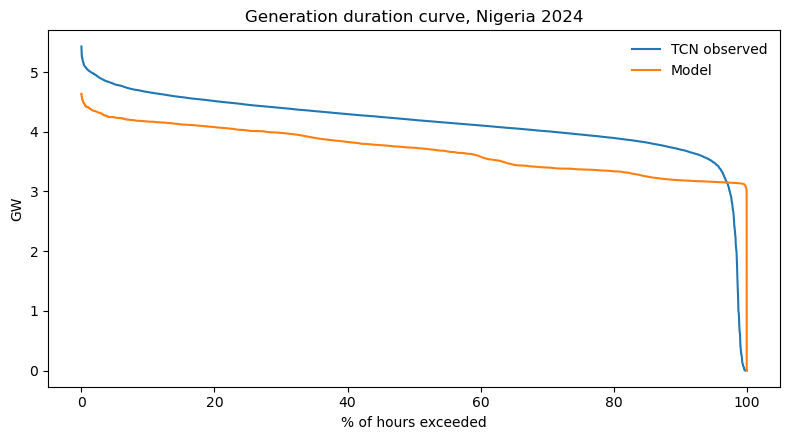

In [786]:
import matplotlib.pyplot as plt

obs = pd.to_numeric(tcn_r["GRAND TOTAL"], errors="coerce").dropna().sort_values(ascending=False).values
mod = dispatch[[c for c in dispatch.columns if c != "load shedding"]].sum(axis=1).sort_values(ascending=False).values

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(obs))/len(obs)*100, obs/1e3, label="TCN observed", lw=1.5)
ax.plot(np.arange(len(mod))/len(mod)*100, mod/1e3, label="Model", lw=1.5)
ax.set_xlabel("% of hours exceeded")
ax.set_ylabel("GW")
ax.set_title("Generation duration curve, Nigeria 2024")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig_duration_curve.png", bbox_inches="tight")
plt.show()